## Mismatch score Analysis

### Regression

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [4]:
ny_llm = pd.read_csv("ny_llm_mismatch_score.csv")
am_llm = pd.read_csv("am_llm_mismatch_score.csv")
datasets = {'NY': ny_llm, 'AM': am_llm}


NY - mabs Basic Statistics
count:    13557
mean:     0.1048
std:      0.0428
skewness: 2.5960
kurtosis: 18.6642
min:      0.0170
25%:      0.0775
50%:      0.0994
75%:      0.1250
95%:      0.1704
99%:      0.2367
max:      0.6135

K-S normality test: stat=0.0713, p=0.0000
→ Reject normality

AM - mabs Basic Statistics
count:    152146
mean:     0.0940
std:      0.0307
skewness: 0.8193
kurtosis: 3.7081
min:      0.0116
25%:      0.0726
50%:      0.0921
75%:      0.1128
95%:      0.1459
99%:      0.1739
max:      0.4720

K-S normality test: stat=0.0262, p=0.0000
→ Reject normality


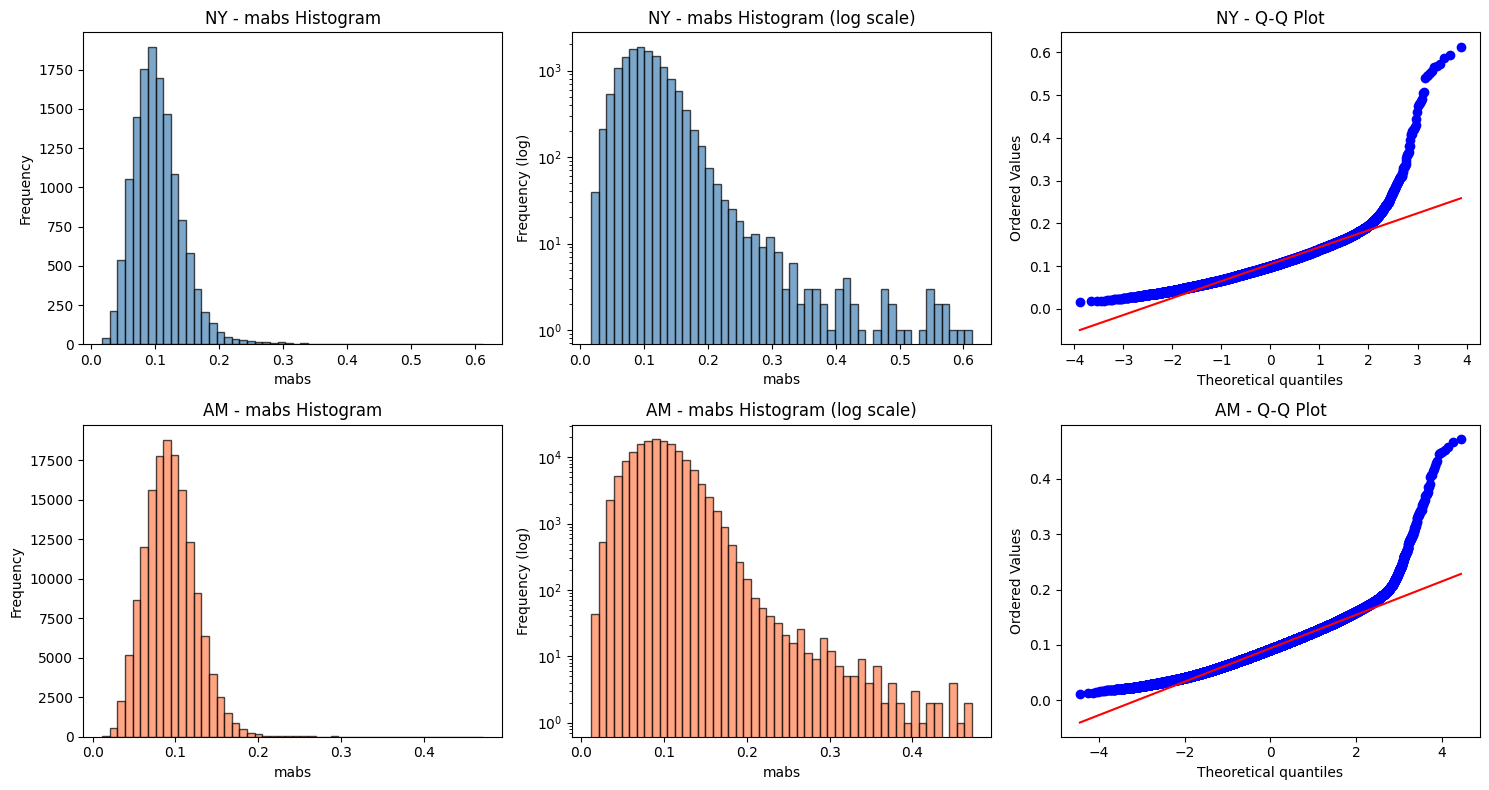


Neighborhood Analysis

NY - unique neighborhoods: 15
Top 10:
neighborhood
SIXTH WARD         4314
SECOND WARD        2635
FOURTEENTH WARD    1266
NINTH WARD         1053
THIRTEENTH WARD     819
FIFTEENTH WARD      670
THIRD WARD          584
TENTH WARD          488
ELEVENTH WARD       437
FOURTH WARD         389
Name: count, dtype: int64

AM - unique neighborhoods: 22
Top 10:
neighborhood
Centrum-West                              36625
Centrum-Oost                              25990
De Baarsjes - Oud-West                    18041
De Pijp - Rivierenbuurt                   14127
Zuid                                       8677
Westerpark                                 7991
Oud-Noord                                  6083
Oud-Oost                                   5552
Oostelijk Havengebied - Indische Buurt     4325
Bos en Lommer                              3553
Name: count, dtype: int64


In [7]:
# ============================================================
# 1. mabs Distribution Analysis
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (city, df) in enumerate(datasets.items()):
    mabs = df['mabs'].dropna()

    print(f"\n{'='*40}")
    print(f"{city} - mabs Basic Statistics")
    print(f"{'='*40}")
    print(f"count:    {len(mabs)}")
    print(f"mean:     {mabs.mean():.4f}")
    print(f"std:      {mabs.std():.4f}")
    print(f"skewness: {mabs.skew():.4f}")
    print(f"kurtosis: {mabs.kurtosis():.4f}")
    print(f"min:      {mabs.min():.4f}")
    print(f"25%:      {mabs.quantile(0.25):.4f}")
    print(f"50%:      {mabs.quantile(0.50):.4f}")
    print(f"75%:      {mabs.quantile(0.75):.4f}")
    print(f"95%:      {mabs.quantile(0.95):.4f}")
    print(f"99%:      {mabs.quantile(0.99):.4f}")
    print(f"max:      {mabs.max():.4f}")

    ks_stat, ks_p = stats.kstest(mabs, 'norm', args=(mabs.mean(), mabs.std()))
    print(f"\nK-S normality test: stat={ks_stat:.4f}, p={ks_p:.4f}")
    print("→ Reject normality" if ks_p < 0.05 else "→ Cannot reject normality")

    color = 'steelblue' if city == 'NY' else 'coral'

    ax1 = axes[i, 0]
    ax1.hist(mabs, bins=50, edgecolor='black', alpha=0.7, color=color)
    ax1.set_title(f'{city} - mabs Histogram')
    ax1.set_xlabel('mabs')
    ax1.set_ylabel('Frequency')

    ax2 = axes[i, 1]
    ax2.hist(mabs, bins=50, edgecolor='black', alpha=0.7, color=color)
    ax2.set_yscale('log')
    ax2.set_title(f'{city} - mabs Histogram (log scale)')
    ax2.set_xlabel('mabs')
    ax2.set_ylabel('Frequency (log)')

    ax3 = axes[i, 2]
    stats.probplot(mabs, dist="norm", plot=ax3)
    ax3.set_title(f'{city} - Q-Q Plot')

plt.tight_layout()
plt.show()

# ============================================================
# 2. Neighborhood Analysis
# ============================================================
print(f"\n{'='*40}")
print("Neighborhood Analysis")
print(f"{'='*40}")

for city, df in datasets.items():
    if 'neighborhood' in df.columns:
        print(f"\n{city} - unique neighborhoods: {df['neighborhood'].nunique()}")
        print(f"Top 10:")
        print(df['neighborhood'].value_counts().head(10))
    else:
        print(f"\n{city} - 'neighborhood' column not found")
        print(f"Available columns: {list(df.columns)}")


1. Distribution of mabs：

- NY：skewness=2.60，kurtosis=18.66，strongly right-skewed + heavy-tail
- AM：skewness=0.82，kurtosis=3.71，light right-skewed
- **need to do log transformation**

2. one-hot encoding for Neighborhood

In [8]:
# ============================================================
# 3. Feature Preparation
# ============================================================
NUMERIC_FEATURES = [
    'price',
    'availability_30', 'availability_60', 'availability_90',
    'availability_365', 'availability_eoy',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
TARGET_COL = 'log_mabs'

def prepare_features(df):
    df = df.copy()

    # Log-transform target
    df['log_mabs'] = np.log(df['mabs'])

    # Log-transform price (also right-skewed)
    df['price'] = np.log1p(df['price'])

    # Availability difference features
    df['avail_diff_365_30'] = df['availability_365'] - df['availability_30']
    df['avail_diff_90_30']  = df['availability_90']  - df['availability_30']

    extra_features = ['avail_diff_365_30', 'avail_diff_90_30']

    # One-hot encode neighborhood
    df = pd.get_dummies(df, columns=['neighborhood'], drop_first=True)
    neighborhood_cols = [c for c in df.columns if c.startswith('neighborhood_')]

    feature_cols = NUMERIC_FEATURES + extra_features + neighborhood_cols

    model_df = df[feature_cols + [TARGET_COL]].dropna()

    X = model_df[feature_cols]
    y = model_df[TARGET_COL]

    return X, y, feature_cols

In [15]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
}

In [16]:
all_results = {}

for city, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"CITY: {city}")
    print(f"{'='*60}")

    X, y, feature_cols = prepare_features(df)
    print(f"Data shape: {X.shape}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    city_results = {}

    for model_name, model in models.items():
        print(f"\n--- {model_name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2   = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"R²:   {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")

        # Feature importance
        importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
        print(f"Top 10 Feature Importances:")
        print(importance.head(10))

        city_results[model_name] = {
            'r2': r2, 'rmse': rmse, 'importance': importance
        }

    all_results[city] = {'results': city_results, 'feature_cols': feature_cols}

    # Summary table
    print(f"\n--- {city} Model Comparison ---")
    print(f"{'Model':<20} {'R²':>8} {'RMSE':>8}")
    print(f"{'-'*40}")
    for model_name, res in city_results.items():
        print(f"{model_name:<20} {res['r2']:>8.4f} {res['rmse']:>8.4f}")


CITY: NY
Data shape: (13557, 28)

--- Random Forest ---
R²:   0.1387
RMSE: 0.3530
Top 10 Feature Importances:
price                          0.148567
review_scores_cleanliness      0.121178
review_scores_value            0.082802
review_scores_accuracy         0.081298
availability_365               0.073988
availability_90                0.071977
review_scores_communication    0.056191
avail_diff_90_30               0.056001
review_scores_location         0.050169
review_scores_checkin          0.046898
dtype: float64

--- XGBoost ---
R²:   0.1316
RMSE: 0.3544
Top 10 Feature Importances:
neighborhood_ELEVENTH WARD      0.086538
avail_diff_90_30                0.078196
neighborhood_THIRTEENTH WARD    0.057397
neighborhood_FIFTEENTH WARD     0.049347
availability_eoy                0.045835
neighborhood_NINTH WARD         0.044792
availability_90                 0.042397
review_scores_cleanliness       0.041881
review_scores_value             0.040162
avail_diff_365_30               0.

We trained three models — Random Forest, XGBoost, and LightGBM — to predict mabs (overall mismatch magnitude) using listing price, neighborhood, availability, and user review scores as features. All three models achieved similar performance, with R² ranging from 0.10 to 0.15 across both cities. LightGBM was selected as the final model (NY R²=0.1471, AM R²=0.1065). Notably, the inclusion of review score features did not lead to meaningful improvements in predictive performance, suggesting that **mismatch largely cannot be explained by conventional listing metrics — reinforcing its value as an independent evaluation dimension**. In terms of feature importance, price, review_scores_cleanliness, review_scores_value, and review_scores_accuracy consistently ranked among the top features in both cities, indicating that pricing positioning and users' perceptions of cleanliness, value, and description accuracy are associated with higher levels of mismatch.

### Correlation & Group Analysis

PART 1: Correlation Analysis (Mismatch vs Rating)

NY
Feature               Pearson r    p-value   Spearman r    p-value
-----------------------------------------------------------------
mismatch_proxy          +0.0976        ***      +0.1321        ***
mabs                    +0.0396        ***      +0.1343        ***
mover                   -0.1338        ***      -0.0845        ***
munder                  +0.1814        ***      +0.1853        ***

NY - Spearman Correlation Matrix:
                mismatch_proxy    mabs   mover  munder  rating
mismatch_proxy          1.0000 -0.1625  0.2215 -0.3599  0.1321
mabs                   -0.1625  1.0000  0.2181  0.5991  0.1343
mover                   0.2215  0.2181  1.0000 -0.5573 -0.0845
munder                 -0.3599  0.5991 -0.5573  1.0000  0.1853
rating                  0.1321  0.1343 -0.0845  0.1853  1.0000

AM
Feature               Pearson r    p-value   Spearman r    p-value
-------------------------------------------------------------

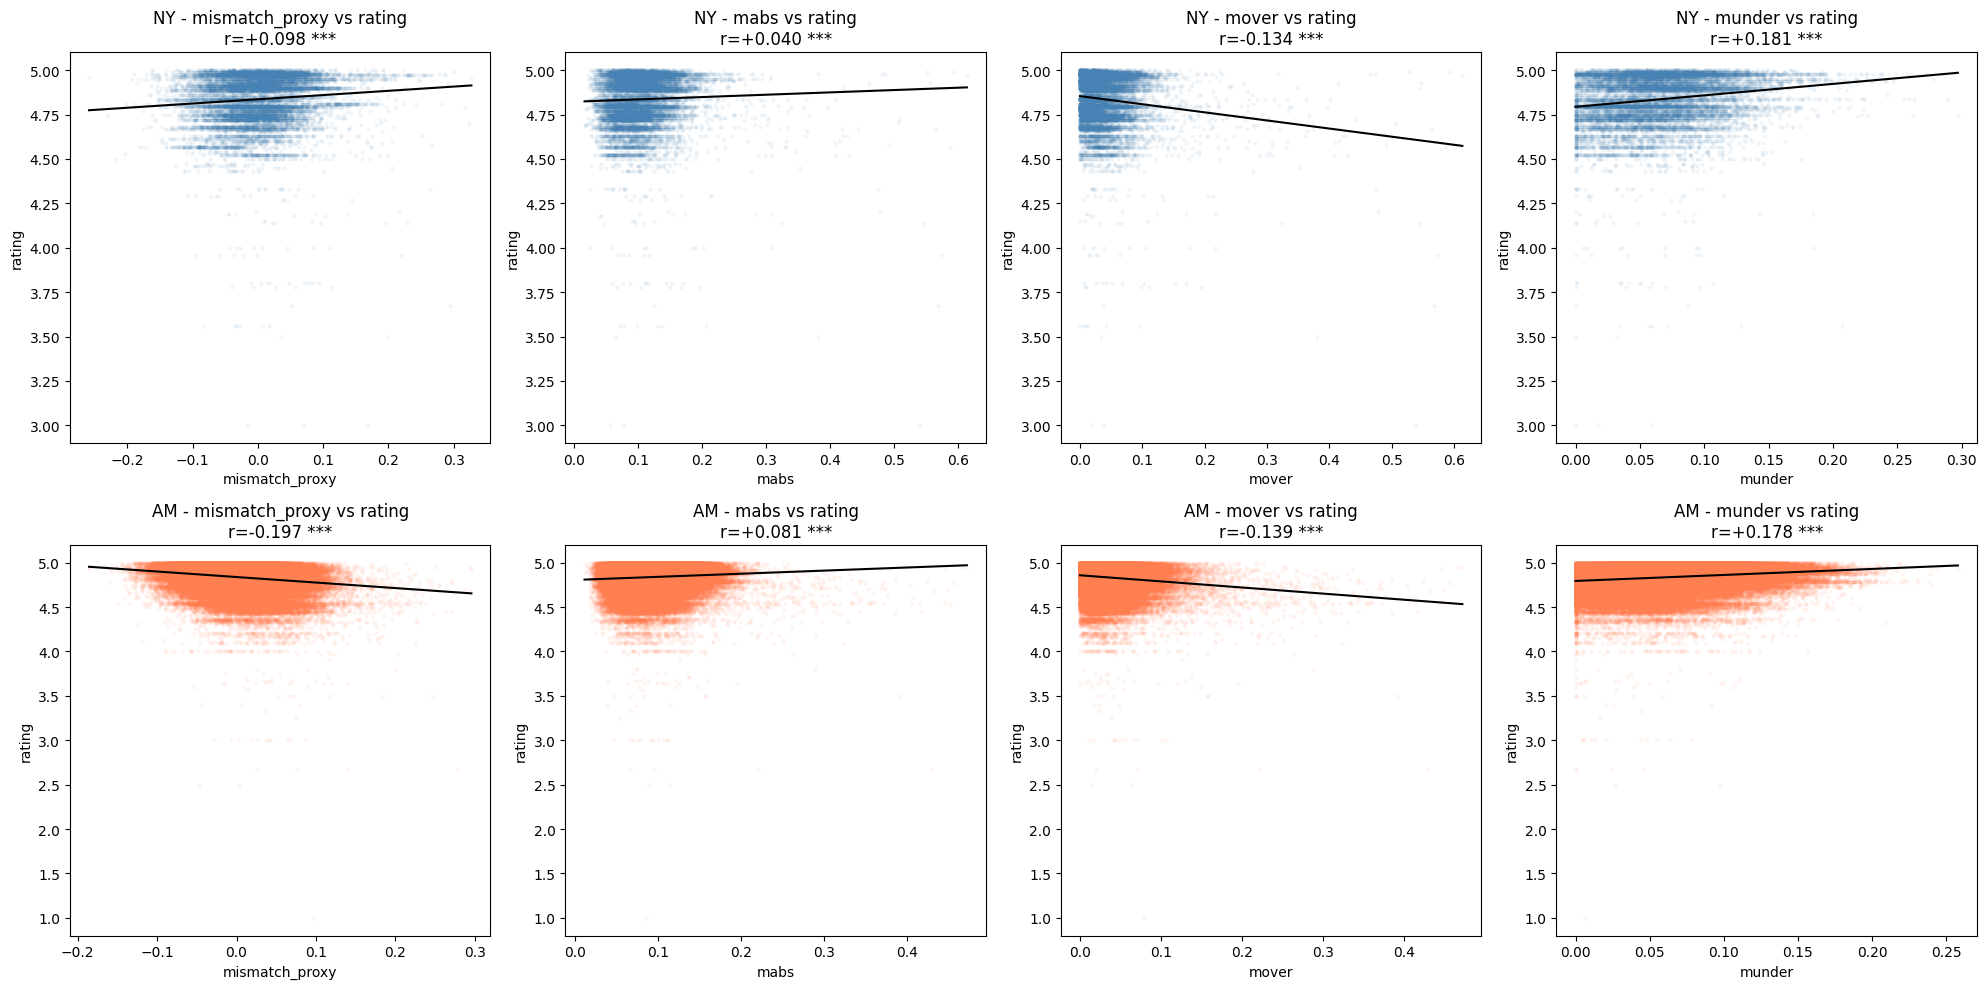


PART 2: Rating Group Analysis

NY - Rating Group Distribution:
rating_group
bottom 33%    4833
mid 33%       4328
top 33%       4396
Name: count, dtype: int64

  mismatch_proxy:
    ANOVA:          F=123.8811, p=4.8411e-54 ***
    Kruskal-Wallis: H=246.6998, p=2.6904e-54   ***
    bottom 33%           mean=-0.0070  std=0.0527  n=4833
    mid 33%              mean=-0.0041  std=0.0606  n=4328
    top 33%              mean=0.0109  std=0.0606  n=4396

  mabs:
    ANOVA:          F=54.9514, p=1.7027e-24 ***
    Kruskal-Wallis: H=210.1603, p=2.3135e-46   ***
    bottom 33%           mean=0.1007  std=0.0467  n=4833
    mid 33%              mean=0.1041  std=0.0388  n=4328
    top 33%              mean=0.1099  std=0.0417  n=4396

  mover:
    ANOVA:          F=37.1824, p=7.8712e-17 ***
    Kruskal-Wallis: H=57.1325, p=3.9251e-13   ***
    bottom 33%           mean=0.0434  std=0.0500  n=4833
    mid 33%              mean=0.0375  std=0.0349  n=4328
    top 33%              mean=0.0365  std=0.037

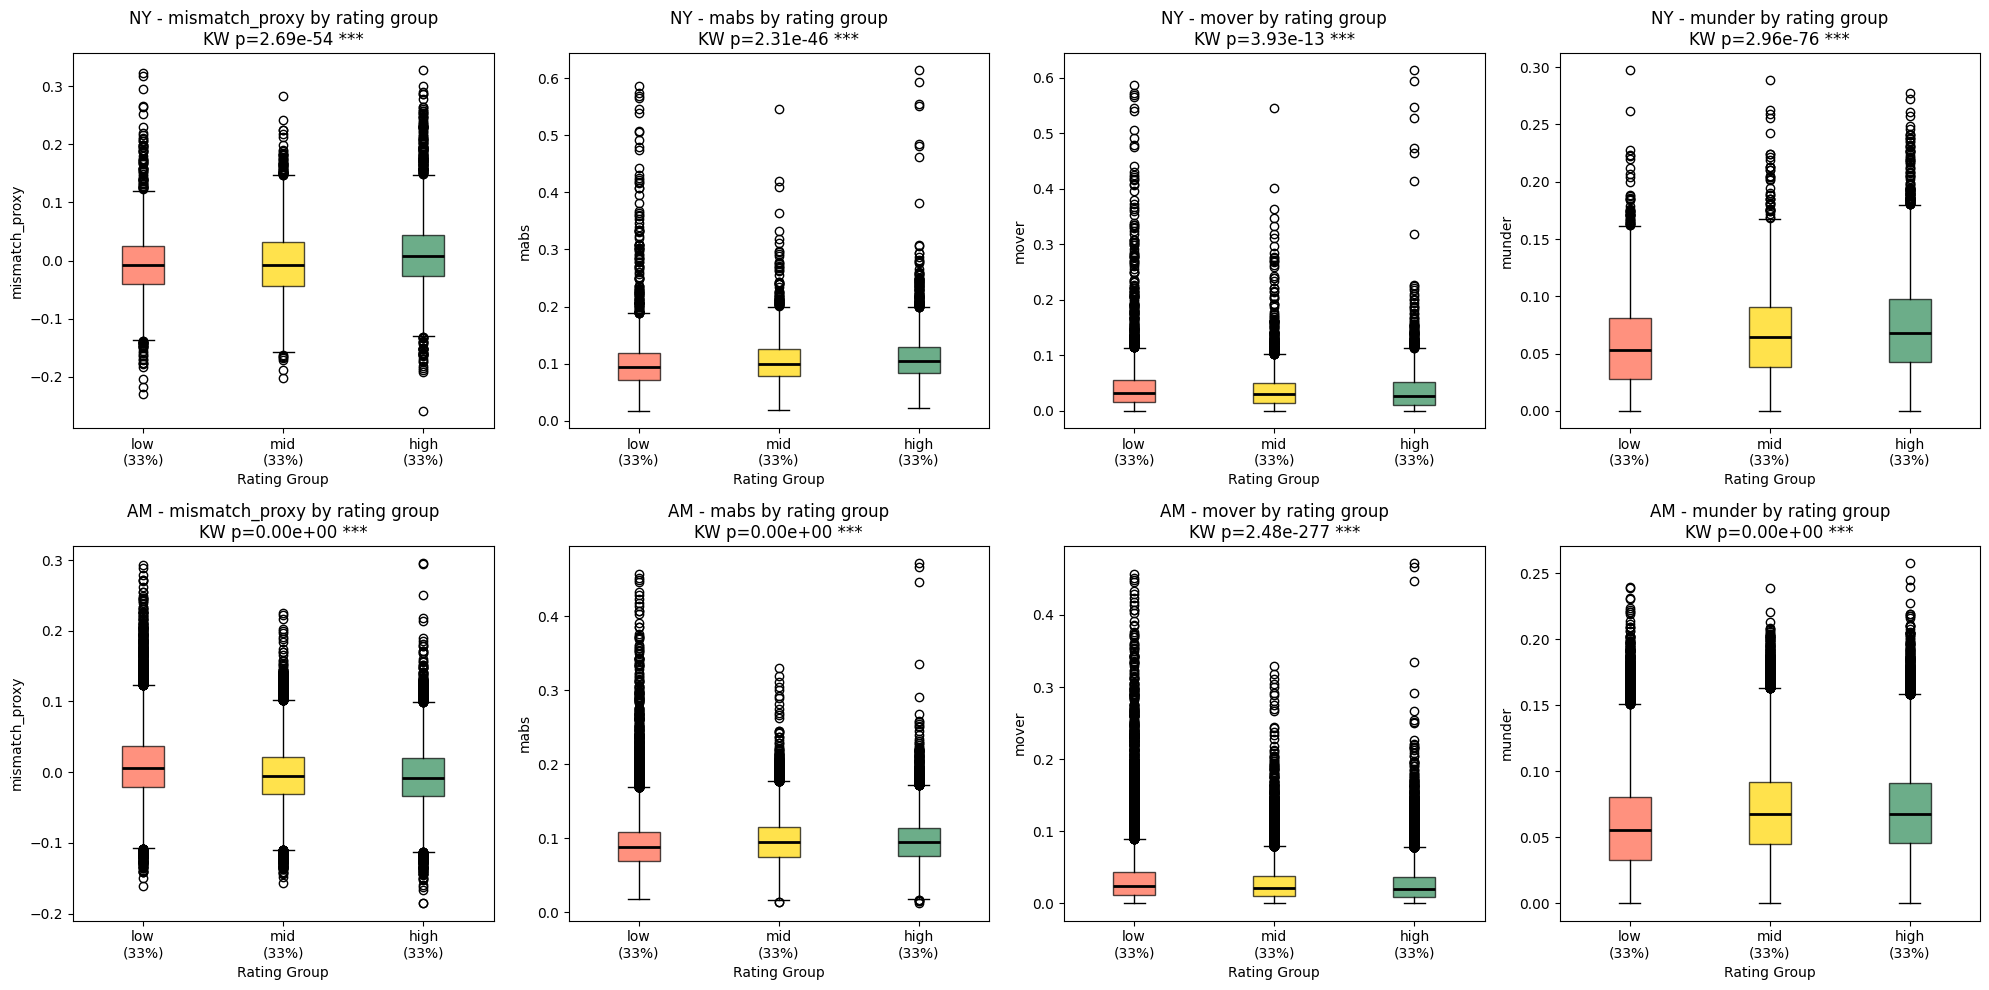


SUMMARY

NY:
  mismatch_proxy       Spearman r=+0.1321 ***
  mabs                 Spearman r=+0.1343 ***
  mover                Spearman r=-0.0845 ***
  munder               Spearman r=+0.1853 ***

AM:
  mismatch_proxy       Spearman r=-0.1698 ***
  mabs                 Spearman r=+0.1050 ***
  mover                Spearman r=-0.1050 ***
  munder               Spearman r=+0.1686 ***


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 0. Load Data
# ============================================================
ny_llm = pd.read_csv('ny_llm_mismatch_score.csv')
am_llm = pd.read_csv('am_llm_mismatch_score.csv')

datasets = {'NY': ny_llm, 'AM': am_llm}

MISMATCH_COLS = ['mismatch_proxy', 'mabs', 'mover', 'munder']

# ============================================================
# 1. Correlation Analysis
# ============================================================
print("=" * 60)
print("PART 1: Correlation Analysis (Mismatch vs Rating)")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (city, df) in enumerate(datasets.items()):
    subset = df[MISMATCH_COLS + ['rating']].dropna()

    # Pearson and Spearman correlations
    print(f"\n{city}")
    print(f"{'Feature':<20} {'Pearson r':>10} {'p-value':>10} {'Spearman r':>12} {'p-value':>10}")
    print(f"{'-'*65}")

    for col in MISMATCH_COLS:
        pearson_r,  pearson_p  = stats.pearsonr(subset[col],  subset['rating'])
        spearman_r, spearman_p = stats.spearmanr(subset[col], subset['rating'])
        sig_p = '***' if pearson_p  < 0.001 else ('**' if pearson_p  < 0.01 else ('*' if pearson_p  < 0.05 else 'ns'))
        sig_s = '***' if spearman_p < 0.001 else ('**' if spearman_p < 0.01 else ('*' if spearman_p < 0.05 else 'ns'))
        print(f"{col:<20} {pearson_r:>+10.4f} {sig_p:>10} {spearman_r:>+12.4f} {sig_s:>10}")

        # Scatter plot
        ax = axes[i, MISMATCH_COLS.index(col)]
        ax.scatter(subset[col], subset['rating'], alpha=0.05, s=5,
                   color='steelblue' if city == 'NY' else 'coral')

        # Regression line
        m, b = np.polyfit(subset[col], subset['rating'], 1)
        x_line = np.linspace(subset[col].min(), subset[col].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5)

        ax.set_title(f'{city} - {col} vs rating\nr={pearson_r:+.3f} {sig_p}')
        ax.set_xlabel(col)
        ax.set_ylabel('rating')

    # Correlation heatmap (print only)
    corr_matrix = subset.corr(method='spearman')
    print(f"\n{city} - Spearman Correlation Matrix:")
    print(corr_matrix.round(4))

plt.tight_layout()
plt.show()

# ============================================================
# 2. Rating Group Analysis (ANOVA + Kruskal-Wallis)
# ============================================================
print("\n" + "=" * 60)
print("PART 2: Rating Group Analysis")
print("=" * 60)

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))

for i, (city, df) in enumerate(datasets.items()):
    subset = df[MISMATCH_COLS + ['rating']].dropna()

    # Define rating groups
    subset = subset.copy()
    # subset['rating_group'] = pd.cut(
    #     subset['rating'],
    #     bins=[0, 4.0, 4.5, 5.0],
    #     labels=['low (<4.0)', 'mid (4.0-4.5)', 'high (>4.5)']
    # )
    subset['rating_group'] = pd.qcut(
        subset['rating'], q=3,
        labels=['bottom 33%', 'mid 33%', 'top 33%']
    )
    subset = subset.dropna(subset=['rating_group'])

    group_counts = subset['rating_group'].value_counts().sort_index()
    print(f"\n{city} - Rating Group Distribution:")
    print(group_counts)

    for j, col in enumerate(MISMATCH_COLS):
        # groups = [
        #     subset[subset['rating_group'] == g][col].dropna().values
        #     for g in ['low (<4.0)', 'mid (4.0-4.5)', 'high (>4.5)']
        # ]
        groups = [
            subset[subset['rating_group'] == g][col].dropna().values
            for g in ['bottom 33%', 'mid 33%', 'top 33%']
        ]

        # ANOVA
        f_stat, anova_p = stats.f_oneway(*groups)

        # Kruskal-Wallis (non-parametric alternative)
        kw_stat, kw_p = stats.kruskal(*groups)

        sig_a = '***' if anova_p < 0.001 else ('**' if anova_p < 0.01 else ('*' if anova_p < 0.05 else 'ns'))
        sig_k = '***' if kw_p   < 0.001 else ('**' if kw_p   < 0.01 else ('*' if kw_p   < 0.05 else 'ns'))

        print(f"\n  {col}:")
        print(f"    ANOVA:          F={f_stat:.4f}, p={anova_p:.4e} {sig_a}")
        print(f"    Kruskal-Wallis: H={kw_stat:.4f}, p={kw_p:.4e}   {sig_k}")

        # Group means
        for g in ['bottom 33%', 'mid 33%', 'top 33%']:
            vals = subset[subset['rating_group'] == g][col]
            print(f"    {g:<20} mean={vals.mean():.4f}  std={vals.std():.4f}  n={len(vals)}")

        # Box plot
        ax = axes2[i, j]
        data_to_plot = [g for g in groups]
        bp = ax.boxplot(data_to_plot,
                        labels=['low\n(33%)', 'mid\n(33%)', 'high\n(33%)'],
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))

        colors_box = ['tomato', 'gold', 'seagreen']
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_title(f'{city} - {col} by rating group\nKW p={kw_p:.2e} {sig_k}')
        ax.set_xlabel('Rating Group')
        ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# ============================================================
# 3. Key Takeaway Summary
# ============================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
for city, df in datasets.items():
    subset = df[MISMATCH_COLS + ['rating']].dropna()
    print(f"\n{city}:")
    for col in MISMATCH_COLS:
        r, p = stats.spearmanr(subset[col], subset['rating'])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {col:<20} Spearman r={r:+.4f} {sig}")

Correlation analysis reveals that all mismatch metrics exhibit weak but statistically significant Spearman correlations with rating (|r| = 0.08–0.19, p < 0.001), indicating that **mismatch captures information largely independent of conventional rating scores**. This pattern holds consistently across both New York and Amsterdam, supporting the validity of mismatch as a complementary evaluation dimension.

Quantile-based group analysis further uncovers two consistent cross-city patterns. First, mover (degree of over-description) increases significantly as user ratings decrease (NY: bottom tercile = 0.043, top tercile = 0.037; AM: bottom tercile = 0.032, top tercile = 0.026), suggesting that **exaggerated listing descriptions are associated with lower user satisfaction**. Second, munder (degree of under-description) increases significantly as user ratings increase (NY: bottom tercile = 0.057, top tercile = 0.073; AM: bottom tercile = 0.059, top tercile = 0.069), indicating that **high-rated listings tend toward conservative self-presentation, where guests' actual experiences exceed their expectations**. Both patterns are statistically robust across ANOVA and Kruskal-Wallis tests (p < 0.001).

Mismatch Metric

- **Independence**: Spearman r between mismatch and rating ranges only from ±0.10 to ±0.19, with rating explaining at most 3.6% of mismatch variance — indicating minimal overlap between the two constructs.
- **Meaningfulness**: Listings with higher mover tend to receive lower ratings, while listings with higher munder tend to receive higher ratings — demonstrating that mismatch carries real directional signal rather than random noise.
- **Interpretability**: Mismatch is grounded in the score differences between descriptions and reviews across 10 semantic dimensions, each with concrete real-world meaning.
- **Cross-city consistency**: Patterns are directionally consistent across both NY and AM — suggesting the findings generalize beyond a single market.

It shows Rating and Mismatch measure fundamentally different things: rating reflects how satisfied users are with their experience, while **mismatch captures how accurately a host represents their listing**. These are two distinct dimensions of platform quality that cannot be reduced to one another, and both are necessary for a complete evaluation.

### Classification


CITY: NY

Target distribution:
  Not disappointed (0): 13411 (98.9%)
  Disappointed    (1): 146 (1.1%)

Train listings: 241
Test  listings: 61

--- Baseline ---
AUC-ROC:          0.7667
F1 (macro):       0.5864
F1 (disappointed):0.1875

Classification Report:
                  precision    recall  f1-score   support

not disappointed       0.99      0.98      0.99      1782
    disappointed       0.14      0.29      0.19        21

        accuracy                           0.97      1803
       macro avg       0.57      0.63      0.59      1803
    weighted avg       0.98      0.97      0.98      1803


--- Full (+mismatch) ---
AUC-ROC:          0.8280
F1 (macro):       0.5951
F1 (disappointed):0.2034

Classification Report:
                  precision    recall  f1-score   support

not disappointed       0.99      0.98      0.99      1782
    disappointed       0.16      0.29      0.20        21

        accuracy                           0.97      1803
       macro avg       0.57  

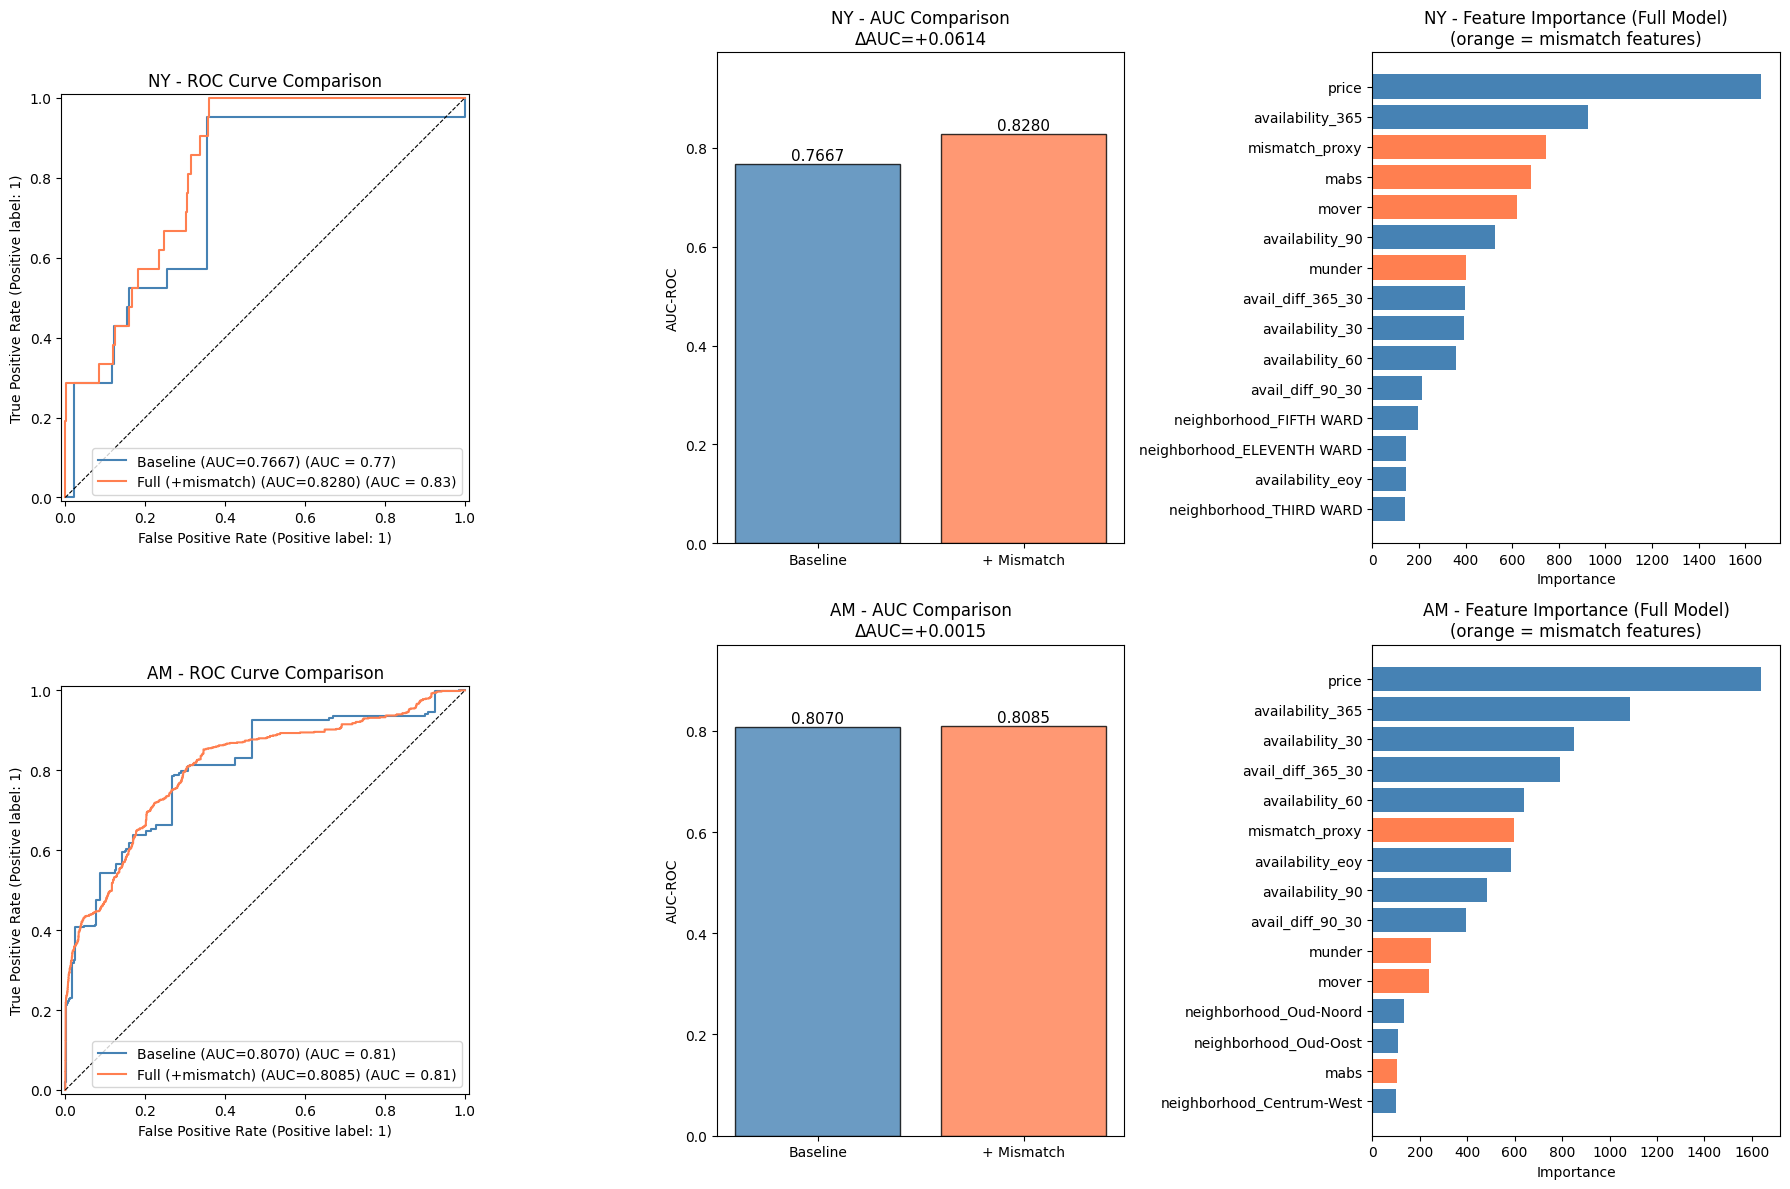


SUMMARY
City     AUC_base   AUC_full     ΔAUC
--------------------------------------
NY         0.7667     0.8280  +0.0614
AM         0.8070     0.8085  +0.0015


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 0. Load Data
# ============================================================
ny_llm = pd.read_csv('ny_llm_mismatch_score.csv')
am_llm = pd.read_csv('am_llm_mismatch_score.csv')

datasets = {'NY': ny_llm, 'AM': am_llm}

# Base features (no mismatch)
BASE_FEATURES = [
    'price',
    'availability_30', 'availability_60', 'availability_90',
    'availability_365', 'availability_eoy'
]

# Mismatch features
MISMATCH_FEATURES = ['mismatch_proxy', 'mabs', 'mover', 'munder']

# ============================================================
# 1. Feature Preparation
# ============================================================
def prepare_data(df):
    df = df.copy()

    # Binary target: disappointed = rating < 4.5
    df['disappointed'] = (df['rating'] < 4.5).astype(int)

    # Log-transform price
    df['price'] = np.log1p(df['price'])

    # Availability difference features
    df['avail_diff_365_30'] = df['availability_365'] - df['availability_30']
    df['avail_diff_90_30']  = df['availability_90']  - df['availability_30']

    # One-hot encode neighborhood
    df = pd.get_dummies(df, columns=['neighborhood'], drop_first=True)
    neighborhood_cols = [c for c in df.columns if c.startswith('neighborhood_')]

    base_cols = BASE_FEATURES + ['avail_diff_365_30', 'avail_diff_90_30'] + neighborhood_cols
    full_cols  = base_cols + MISMATCH_FEATURES

    return df, base_cols, full_cols

# ============================================================
# 2. Train & Evaluate
# ============================================================
all_results = {}

for city, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"CITY: {city}")
    print(f"{'='*60}")

    df_prep, base_cols, full_cols = prepare_data(df)

    needed   = full_cols + ['disappointed', 'listing_id']
    model_df = df_prep[needed].dropna()

    X_base = model_df[base_cols]
    X_full = model_df[full_cols]
    y      = model_df['disappointed']
    groups = model_df['listing_id']

    # Class distribution
    print(f"\nTarget distribution:")
    print(f"  Not disappointed (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
    print(f"  Disappointed    (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

    # GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X_base, y, groups=groups))

    X_base_train = X_base.iloc[train_idx]
    X_base_test  = X_base.iloc[test_idx]
    X_full_train = X_full.iloc[train_idx]
    X_full_test  = X_full.iloc[test_idx]
    y_train      = y.iloc[train_idx]
    y_test       = y.iloc[test_idx]

    print(f"\nTrain listings: {groups.iloc[train_idx].nunique()}")
    print(f"Test  listings: {groups.iloc[test_idx].nunique()}")

    city_results = {'y_test': y_test}

    for label, X_tr, X_te in [('Baseline', X_base_train, X_base_test),
                                ('Full (+mismatch)', X_full_train, X_full_test)]:

        model = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(X_tr, y_train)

        y_pred      = model.predict(X_te)
        y_pred_prob = model.predict_proba(X_te)[:, 1]

        auc = roc_auc_score(y_test, y_pred_prob)
        f1  = f1_score(y_test, y_pred, average='macro')
        f1_minority = f1_score(y_test, y_pred, pos_label=1)

        print(f"\n--- {label} ---")
        print(f"AUC-ROC:          {auc:.4f}")
        print(f"F1 (macro):       {f1:.4f}")
        print(f"F1 (disappointed):{f1_minority:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['not disappointed', 'disappointed']))

        city_results[label] = {
            'model':       model,
            'auc':         auc,
            'f1':          f1,
            'f1_minority': f1_minority,
            'y_pred_prob': y_pred_prob,
            'feature_cols': base_cols if label == 'Baseline' else full_cols
        }

    # Delta AUC
    delta_auc = city_results['Full (+mismatch)']['auc'] - city_results['Baseline']['auc']
    print(f"\n--- Incremental Value of Mismatch ---")
    print(f"ΔAUC: {delta_auc:+.4f}")
    if abs(delta_auc) < 0.01:
        print("→ Mismatch provides minimal incremental value for predicting rating")
        print("→ This further supports mismatch as an independent dimension from rating")
    else:
        print("→ Mismatch provides meaningful incremental predictive value")

    all_results[city] = city_results

# ============================================================
# 3. Visualization
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, (city, results) in enumerate(all_results.items()):

    # --- ROC Curve comparison ---
    ax1 = axes[i, 0]
    y_test_city = results['y_test']
    for label, color in [('Baseline', 'steelblue'), ('Full (+mismatch)', 'coral')]:
        res = results[label]
        RocCurveDisplay.from_predictions(
            y_test_city,
            res['y_pred_prob'],
            name=f"{label} (AUC={res['auc']:.4f})",
            ax=ax1,
            color=color
        )
    ax1.plot([0,1], [0,1], 'k--', linewidth=0.8)
    ax1.set_title(f'{city} - ROC Curve Comparison')

    # --- AUC bar chart ---
    ax2 = axes[i, 1]
    labels = ['Baseline', '+ Mismatch']
    aucs   = [results['Baseline']['auc'], results['Full (+mismatch)']['auc']]
    bars   = ax2.bar(labels, aucs, color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
    for bar, val in zip(bars, aucs):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
    delta = aucs[1] - aucs[0]
    ax2.set_title(f'{city} - AUC Comparison\nΔAUC={delta:+.4f}')
    ax2.set_ylabel('AUC-ROC')
    ax2.set_ylim(0, max(aucs) * 1.2)

    # --- Feature importance (full model) ---
    ax3 = axes[i, 2]
    full_model    = results['Full (+mismatch)']['model']
    feature_cols  = results['Full (+mismatch)']['feature_cols']
    imp           = pd.Series(full_model.feature_importances_, index=feature_cols)
    top15         = imp.sort_values(ascending=False).head(15)
    colors        = ['coral' if f in MISMATCH_FEATURES else 'steelblue' for f in top15.index[::-1]]
    ax3.barh(top15.index[::-1], top15.values[::-1], color=colors)
    ax3.set_title(f'{city} - Feature Importance (Full Model)\n(orange = mismatch features)')
    ax3.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# ============================================================
# 4. Summary
# ============================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"{'City':<6} {'AUC_base':>10} {'AUC_full':>10} {'ΔAUC':>8}")
print(f"{'-'*38}")
for city, results in all_results.items():
    auc_base = results['Baseline']['auc']
    auc_full = results['Full (+mismatch)']['auc']
    delta    = auc_full - auc_base
    print(f"{city:<6} {auc_base:>10.4f} {auc_full:>10.4f} {delta:>+8.4f}")

In order to assess whether mismatch carries incremental predictive value beyond conventional listing attributes, we trained a binary classifier (LightGBM) to predict user disappointment (rating < 4.5) under two conditions: a baseline model using only price, neighborhood, and availability, and a full model with mismatch features added. 

In the AM dataset, where sample size is sufficient for reliable evaluation, adding mismatch features yields a marginal AUC improvement of only 0.0015, indicating that mismatch provides virtually no incremental predictive value for user ratings. This is consistent with the findings from our correlation analysis — **mismatch and rating represent two fundamentally distinct dimensions, where mismatch captures the accuracy of a host's self-presentation rather than user satisfaction itself**.

## Correlation between mismatch and user behavior

### OLS Regression: Mismatch Metrics vs. Review Volume with Confounders

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
DATA_FILES = {
    "NY": "ny_llm_mismatch_score.csv",
    "MO": "mo_llm_mismatch_score.csv",
    "AM": "am_llm_mismatch_score.csv",
}

# ============================================================
# LOAD
# ============================================================
def load_and_prep(path, city):
    df = pd.read_csv(path)
    df["city"] = city
    df["date"] = pd.to_datetime(df["date"])
    return df

dfs = {}
for city, path in DATA_FILES.items():
    try:
        dfs[city] = load_and_prep(path, city)
        print(f"Loaded {city}: {len(dfs[city])} rows")
    except FileNotFoundError:
        print(f"File not found: {path}, skipping.")

# ============================================================
# AGGREGATE TO LISTING LEVEL
# ============================================================
def build_listing_df(df):
    agg = (
        df.groupby("listing_id")
        .agg(
            total_reviews   = ("review_id", "count"),
            avg_mover       = ("mover",     "mean"),
            avg_munder      = ("munder",    "mean"),
            avg_mabs        = ("mabs",      "mean"),
            avg_rating      = ("rating",    "mean"),
            price           = ("price",     "first"),   # price is listing-level
            neighborhood    = ("neighborhood", "first"),
            first_review    = ("date",      "min"),
            last_review     = ("date",      "max"),
        )
        .reset_index()
    )

    # listing_age in months (proxy)
    agg["listing_age_months"] = (
        (agg["last_review"] - agg["first_review"]).dt.days / 30
    ).clip(lower=1)  # avoid 0

    # log-transform total_reviews (right-skewed)
    agg["log_reviews"] = np.log1p(agg["total_reviews"])

    # clean price: remove "$", ",", convert to float
    agg["price"] = (
        agg["price"].astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .str.strip()
    )
    agg["price"] = pd.to_numeric(agg["price"], errors="coerce")
    agg["log_price"] = np.log1p(agg["price"])

    # drop rows with missing key vars
    agg = agg.dropna(subset=["avg_mover", "log_price", "neighborhood", "listing_age_months"])

    return agg

listing_dfs = {}
for city, df in dfs.items():
    listing_dfs[city] = build_listing_df(df)
    print(f"{city} listing-level: {len(listing_dfs[city])} listings")

# ============================================================
# OLS REGRESSION per city
# formula: log_reviews ~ avg_mover + avg_munder + log_price + listing_age_months + C(neighborhood)
# ============================================================
print("\n" + "="*60)
print("OLS Regression: log_reviews ~ mover + munder + price + age + neighborhood")
print("="*60)

results = {}
for city, ldf in listing_dfs.items():
    print(f"\n--- {city} ---")

    # Check neighborhood cardinality
    n_hoods = ldf["neighborhood"].nunique()
    print(f"  Neighborhoods: {n_hoods}")

    formula = "log_reviews ~ avg_mover + avg_munder + log_price + listing_age_months + C(neighborhood)"

    try:
        model = smf.ols(formula, data=ldf).fit()
        results[city] = model

        # Print key coefficients only (not all neighborhood dummies)
        key_vars = ["Intercept", "avg_mover", "avg_munder", "log_price", "listing_age_months"]
        print(f"\n  {'Variable':<25} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p':>8}")
        print(f"  {'-'*65}")
        for var in key_vars:
            if var in model.params:
                coef = model.params[var]
                se   = model.bse[var]
                t    = model.tvalues[var]
                p    = model.pvalues[var]
                sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
                print(f"  {var:<25} {coef:>10.4f} {se:>10.4f} {t:>8.3f} {p:>8.4f} {sig}")

        print(f"\n  R² = {model.rsquared:.4f}  |  Adj. R² = {model.rsquared_adj:.4f}  |  N = {int(model.nobs)}")

    except Exception as e:
        print(f"  Error: {e}")

# ============================================================
# INTERPRETATION SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY: avg_mover & avg_munder coefficients")
print("="*60)
print(f"  {'City':<6} {'Var':<12} {'Coef':>10} {'p-value':>10} {'Significant?':>14}")
print(f"  {'-'*55}")
for city, model in results.items():
    for var in ["avg_mover", "avg_munder"]:
        if var in model.params:
            coef = model.params[var]
            p    = model.pvalues[var]
            sig  = "Yes ***" if p < 0.001 else ("Yes **" if p < 0.01 else ("Yes *" if p < 0.05 else "No"))
            print(f"  {city:<6} {var:<12} {coef:>10.4f} {p:>10.4f} {sig:>14}")

Loaded NY: 13557 rows
Loaded MO: 140236 rows
Loaded AM: 152146 rows
NY listing-level: 302 listings
MO listing-level: 4743 listings
AM listing-level: 4113 listings

OLS Regression: log_reviews ~ mover + munder + price + age + neighborhood

--- NY ---
  Neighborhoods: 15

  Variable                        Coef    Std Err        t        p
  -----------------------------------------------------------------
  Intercept                     0.8045     0.6856    1.173   0.2417 
  avg_mover                    -0.6437     1.3865   -0.464   0.6428 
  avg_munder                    6.4089     2.1423    2.992   0.0030 **
  log_price                     0.2573     0.1144    2.249   0.0253 *
  listing_age_months            0.0330     0.0018   18.422   0.0000 ***

  R² = 0.6147  |  Adj. R² = 0.5902  |  N = 302

--- MO ---
  Neighborhoods: 32

  Variable                        Coef    Std Err        t        p
  -----------------------------------------------------------------
  Intercept              

After controlling for price, neighborhood, and listing age, 
- over-description (mover) is significantly associated with fewer reviews in MO (β = −3.72, p < .001), suggesting a behavioral penalty for inflated listings. 
- In NY, under-description (munder) is positively associated with review volume (β = 6.41, p = .003), consistent with the pattern that conservative descriptions lead to positive surprises and higher engagement. 
- No significant effects are observed in AM, potentially reflecting the distinct dynamics of a tourist-driven short-term rental market.

### STRATIFIED REGRESSION BY RATING (threshold = 4.5)

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
DATA_FILES = {
    "NY": "ny_llm_mismatch_score.csv",
    "MO": "mo_llm_mismatch_score.csv",
    "AM": "am_llm_mismatch_score.csv",
}

# ============================================================
# LOAD
# ============================================================
def load_and_prep(path, city):
    df = pd.read_csv(path)
    df["city"] = city
    df["date"] = pd.to_datetime(df["date"])
    return df

dfs = {}
for city, path in DATA_FILES.items():
    try:
        dfs[city] = load_and_prep(path, city)
        print(f"Loaded {city}: {len(dfs[city])} rows")
    except FileNotFoundError:
        print(f"File not found: {path}, skipping.")

# ============================================================
# AGGREGATE TO LISTING LEVEL
# ============================================================
def build_listing_df(df):
    agg = (
        df.groupby("listing_id")
        .agg(
            total_reviews   = ("review_id", "count"),
            avg_mover       = ("mover",     "mean"),
            avg_munder      = ("munder",    "mean"),
            avg_mabs        = ("mabs",      "mean"),
            avg_rating      = ("rating",    "mean"),
            price           = ("price",     "first"),   # price is listing-level
            neighborhood    = ("neighborhood", "first"),
            first_review    = ("date",      "min"),
            last_review     = ("date",      "max"),
        )
        .reset_index()
    )

    # listing_age in months (proxy)
    agg["listing_age_months"] = (
        (agg["last_review"] - agg["first_review"]).dt.days / 30
    ).clip(lower=1)  # avoid 0

    # log-transform total_reviews (right-skewed)
    agg["log_reviews"] = np.log1p(agg["total_reviews"])

    # clean price: remove "$", ",", convert to float
    agg["price"] = (
        agg["price"].astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .str.strip()
    )
    agg["price"] = pd.to_numeric(agg["price"], errors="coerce")
    agg["log_price"] = np.log1p(agg["price"])

    # drop rows with missing key vars
    agg = agg.dropna(subset=["avg_mover", "log_price", "neighborhood", "listing_age_months"])

    return agg

listing_dfs = {}
for city, df in dfs.items():
    listing_dfs[city] = build_listing_df(df)
    print(f"{city} listing-level: {len(listing_dfs[city])} listings")

# ============================================================
# OLS REGRESSION per city
# formula: log_reviews ~ avg_mover + log_price + listing_age_months + C(neighborhood)
# ============================================================
print("\n" + "="*60)
print("OLS Regression: log_reviews ~ mover + munder + price + age + neighborhood")
print("="*60)

results = {}
for city, ldf in listing_dfs.items():
    print(f"\n--- {city} ---")

    # Check neighborhood cardinality
    n_hoods = ldf["neighborhood"].nunique()
    print(f"  Neighborhoods: {n_hoods}")

    formula = "log_reviews ~ avg_mover + avg_munder + log_price + listing_age_months + C(neighborhood)"

    try:
        model = smf.ols(formula, data=ldf).fit()
        results[city] = model

        # Print key coefficients only (not all neighborhood dummies)
        key_vars = ["Intercept", "avg_mover", "avg_munder", "log_price", "listing_age_months"]
        print(f"\n  {'Variable':<25} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p':>8}")
        print(f"  {'-'*65}")
        for var in key_vars:
            if var in model.params:
                coef = model.params[var]
                se   = model.bse[var]
                t    = model.tvalues[var]
                p    = model.pvalues[var]
                sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
                print(f"  {var:<25} {coef:>10.4f} {se:>10.4f} {t:>8.3f} {p:>8.4f} {sig}")

        print(f"\n  R² = {model.rsquared:.4f}  |  Adj. R² = {model.rsquared_adj:.4f}  |  N = {int(model.nobs)}")

    except Exception as e:
        print(f"  Error: {e}")

# ============================================================
# INTERPRETATION SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY: avg_mover & avg_munder coefficients")
print("="*60)
print(f"  {'City':<6} {'Var':<12} {'Coef':>10} {'p-value':>10} {'Significant?':>14}")
print(f"  {'-'*55}")
for city, model in results.items():
    for var in ["avg_mover", "avg_munder"]:
        if var in model.params:
            coef = model.params[var]
            p    = model.pvalues[var]
            sig  = "Yes ***" if p < 0.001 else ("Yes **" if p < 0.01 else ("Yes *" if p < 0.05 else "No"))
            print(f"  {city:<6} {var:<12} {coef:>10.4f} {p:>10.4f} {sig:>14}")

# ============================================================
# STRATIFIED REGRESSION BY RATING (threshold = 4.5)
# ============================================================
RATING_THRESHOLD = 4.5

print("\n" + "="*60)
print(f"STRATIFIED REGRESSION: rating < {RATING_THRESHOLD} vs >= {RATING_THRESHOLD}")
print("="*60)

for city, ldf in listing_dfs.items():
    low  = ldf[ldf["avg_rating"] <  RATING_THRESHOLD].copy()
    high = ldf[ldf["avg_rating"] >= RATING_THRESHOLD].copy()

    print(f"\n--- {city}  |  Low-rating n={len(low)}  |  High-rating n={len(high)} ---")

    for label, subdf in [("Low rating  (<4.5)", low), ("High rating (>=4.5)", high)]:
        if len(subdf) < 30:
            print(f"  [{label}] Too few samples ({len(subdf)}), skipping.")
            continue

        # Drop neighborhoods with only 1 listing (causes rank deficiency)
        hood_counts = subdf["neighborhood"].value_counts()
        valid_hoods = hood_counts[hood_counts > 1].index
        subdf = subdf[subdf["neighborhood"].isin(valid_hoods)]

        try:
            model = smf.ols(
                "log_reviews ~ avg_mover + avg_munder + log_price + listing_age_months + C(neighborhood)",
                data=subdf
            ).fit()

            print(f"\n  [{label}]  N={int(model.nobs)}  R²={model.rsquared:.4f}")
            print(f"  {'Variable':<25} {'Coef':>10} {'Std Err':>10} {'t':>8} {'p':>8}")
            print(f"  {'-'*65}")
            for var in ["avg_mover", "avg_munder", "log_price", "listing_age_months"]:
                if var in model.params:
                    coef = model.params[var]
                    se   = model.bse[var]
                    t    = model.tvalues[var]
                    p    = model.pvalues[var]
                    sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
                    print(f"  {var:<25} {coef:>10.4f} {se:>10.4f} {t:>8.3f} {p:>8.4f} {sig}")

        except Exception as e:
            print(f"  [{label}] Error: {e}")

# ============================================================
# STRATIFIED SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("STRATIFIED SUMMARY: avg_mover coefficient by rating group")
print("="*60)
print(f"  {'City':<6} {'Group':<20} {'Coef':>10} {'p-value':>10} {'Significant?':>14}")
print(f"  {'-'*65}")

for city, ldf in listing_dfs.items():
    for label, subdf in [
        ("Low  (<4.5)",  ldf[ldf["avg_rating"] <  RATING_THRESHOLD].copy()),
        ("High (>=4.5)", ldf[ldf["avg_rating"] >= RATING_THRESHOLD].copy()),
    ]:
        if len(subdf) < 30:
            print(f"  {city:<6} {label:<20} {'N too small':>35}")
            continue

        hood_counts = subdf["neighborhood"].value_counts()
        valid_hoods = hood_counts[hood_counts > 1].index
        subdf = subdf[subdf["neighborhood"].isin(valid_hoods)]

        try:
            model = smf.ols(
                "log_reviews ~ avg_mover + avg_munder + log_price + listing_age_months + C(neighborhood)",
                data=subdf
            ).fit()
            coef = model.params.get("avg_mover", np.nan)
            p    = model.pvalues.get("avg_mover", np.nan)
            sig  = "Yes ***" if p < 0.001 else ("Yes **" if p < 0.01 else ("Yes *" if p < 0.05 else "No"))
            print(f"  {city:<6} {label:<20} {coef:>10.4f} {p:>10.4f} {sig:>14}")
        except Exception as e:
            print(f"  {city:<6} {label:<20} Error: {e}")

Loaded NY: 13557 rows
Loaded MO: 140236 rows
Loaded AM: 152146 rows
NY listing-level: 302 listings
MO listing-level: 4743 listings
AM listing-level: 4113 listings

OLS Regression: log_reviews ~ mover + munder + price + age + neighborhood

--- NY ---
  Neighborhoods: 15

  Variable                        Coef    Std Err        t        p
  -----------------------------------------------------------------
  Intercept                     0.8045     0.6856    1.173   0.2417 
  avg_mover                    -0.6437     1.3865   -0.464   0.6428 
  avg_munder                    6.4089     2.1423    2.992   0.0030 **
  log_price                     0.2573     0.1144    2.249   0.0253 *
  listing_age_months            0.0330     0.0018   18.422   0.0000 ***

  R² = 0.6147  |  Adj. R² = 0.5902  |  N = 302

--- MO ---
  Neighborhoods: 32

  Variable                        Coef    Std Err        t        p
  -----------------------------------------------------------------
  Intercept              

**Key Finding: mover effect is negative for low-rated listings and positive for high-rated listings — consistent across cities.**

**Low-rating group (<4.5): significant negative effect in NY and MO**
- Higher over-description → fewer reviews
- Low rating + over-description = double penalty: guests leave disappointed and don't return or recommend

**High-rating group (>=4.5): no significant negative effect in NY and MO; AM shows positive significance**
- Over-description has no negative impact when guest experience is good — booking behavior is unaffected even with some mismatch
- AM's positive effect in the high-rating group suggests that in tourist-driven markets, attention-grabbing descriptions may actually attract more bookings

---

**munder pattern is also notable:**
- MO and NY high-rating group: munder is significantly negative — under-description hurts review volume even for good listings, suggesting conservative descriptions are a missed opportunity
- NY low-rating group: munder is not significant